# STAT 565 Homework 5
# Artem Ivaniuk

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv('m-unrate.txt', sep=r'\s+', header=0)
df['date'] = pd.to_datetime(df[['Year', 'Mon', 'Day']].rename(columns={'Year': 'year', 'Mon': 'month', 'Day': 'day'}))
xt = df.set_index('date')['Rate']

# y_t = Delta x_t
yt = xt.diff().dropna()

Part (a): AR(12) model

In [26]:
model_full = ARIMA(yt, order=(12, 0, 0))
fit_full = model_full.fit()

print("AR(12) Model Summary:")
print(fit_full.summary())

AR(12) Model Summary:
                               SARIMAX Results                                
Dep. Variable:                   Rate   No. Observations:                  734
Model:                ARIMA(12, 0, 0)   Log Likelihood                 153.294
Date:                Mon, 23 Mar 2026   AIC                           -278.587
Time:                        14:45:52   BIC                           -214.208
Sample:                    02-01-1948   HQIC                          -253.756
                         - 03-01-2009                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0075      0.013      0.571      0.568      -0.018       0.033
ar.L1          0.0104      0.026      0.401      0.688      -0.041       0.061
ar.L2          0.2238      0.0

In [27]:
sigma2_a = fit_full.params['sigma2']
print(f"Residual variance (sigma^2_a): {sigma2_a:.6f}")
print(f"Residual std (sigma_a): {np.sqrt(sigma2_a):.6f}")

Residual variance (sigma^2_a): 0.038515
Residual std (sigma_a): 0.196252


In [28]:
params = fit_full.params
stderr = fit_full.bse

print("Parameter estimates and standard errors:")
print("-" * 50)
for name in params.index:
    print(f"{name:12s}: estimate = {params[name]:10.6f},  std err = {stderr[name]:10.6f}")

Parameter estimates and standard errors:
--------------------------------------------------
const       : estimate =   0.007485,  std err =   0.013120
ar.L1       : estimate =   0.010422,  std err =   0.025993
ar.L2       : estimate =   0.223836,  std err =   0.036980
ar.L3       : estimate =   0.161333,  std err =   0.036587
ar.L4       : estimate =   0.101795,  std err =   0.042872
ar.L5       : estimate =   0.122998,  std err =   0.034847
ar.L6       : estimate =  -0.007795,  std err =   0.033032
ar.L7       : estimate =  -0.035289,  std err =   0.043908
ar.L8       : estimate =   0.012339,  std err =   0.039985
ar.L9       : estimate =   0.001763,  std err =   0.038065
ar.L10      : estimate =  -0.111561,  std err =   0.037980
ar.L11      : estimate =   0.028864,  std err =   0.036492
ar.L12      : estimate =  -0.122021,  std err =   0.038643
sigma2      : estimate =   0.038515,  std err =   0.001382


Part (b): Forecast April–July 2009

In [29]:
# Forecast 4 months: Apr, May, Jun, Jul 2009
forecast_b = fit_full.get_forecast(steps=4)
pred_mean_b = forecast_b.predicted_mean
pred_ci_b = forecast_b.conf_int(alpha=0.05)

months_b = ['2009-04', '2009-05', '2009-06', '2009-07']
results_b = pd.DataFrame({
    'Month': months_b,
    'Forecast': pred_mean_b.values,
    'Lower 95%': pred_ci_b.iloc[:, 0].values,
    'Upper 95%': pred_ci_b.iloc[:, 1].values
})
results_b.index = pred_mean_b.index

print("Forecasts for April–July 2009 (yt = change in unemployment rate):")
print(results_b.to_string())

Forecasts for April–July 2009 (yt = change in unemployment rate):
              Month  Forecast  Lower 95%  Upper 95%
2009-04-01  2009-04  0.267050  -0.117597   0.651697
2009-05-01  2009-05  0.175531  -0.209137   0.560199
2009-06-01  2009-06  0.172142  -0.222053   0.566337
2009-07-01  2009-07  0.136297  -0.263036   0.535629


Part (c): Refit with data until December 2007

In [30]:
yt_dec2007 = yt.loc[yt.index <= '2007-12']
model_dec2007 = ARIMA(yt_dec2007, order=(12, 0, 0))
fit_dec2007 = model_dec2007.fit()

forecast_15 = fit_dec2007.get_forecast(steps=15)
pred_mean_15 = forecast_15.predicted_mean
pred_ci_15 = forecast_15.conf_int(alpha=0.05)

print("Forecast origin: December 2007")
print("15-month forecasts (Jan 2008 – Mar 2009):")
results_15 = pd.DataFrame({
    'Forecast': pred_mean_15.values,
    'Lower 95%': pred_ci_15.iloc[:, 0].values,
    'Upper 95%': pred_ci_15.iloc[:, 1].values
}, index=pred_mean_15.index)
print(results_15)

Forecast origin: December 2007
15-month forecasts (Jan 2008 – Mar 2009):
            Forecast  Lower 95%  Upper 95%
2008-01-01 -0.014453  -0.398097   0.369191
2008-02-01  0.078349  -0.305296   0.461993
2008-03-01  0.069680  -0.322301   0.461661
2008-04-01  0.004499  -0.391817   0.400815
2008-05-01  0.080780  -0.319293   0.480853
2008-06-01 -0.007792  -0.413881   0.398297
2008-07-01  0.012367  -0.394548   0.419282
2008-08-01  0.027633  -0.379914   0.435180
2008-09-01 -0.004811  -0.413706   0.404084
2008-10-01 -0.016666  -0.425975   0.392643
2008-11-01  0.014117  -0.395817   0.424050
2008-12-01 -0.048254  -0.458746   0.362238
2009-01-01  0.002231  -0.411977   0.416438
2009-02-01 -0.018001  -0.432213   0.396212
2009-03-01 -0.024249  -0.439152   0.390654


Part (d): Plot true observations, forecasts, and prediction intervals

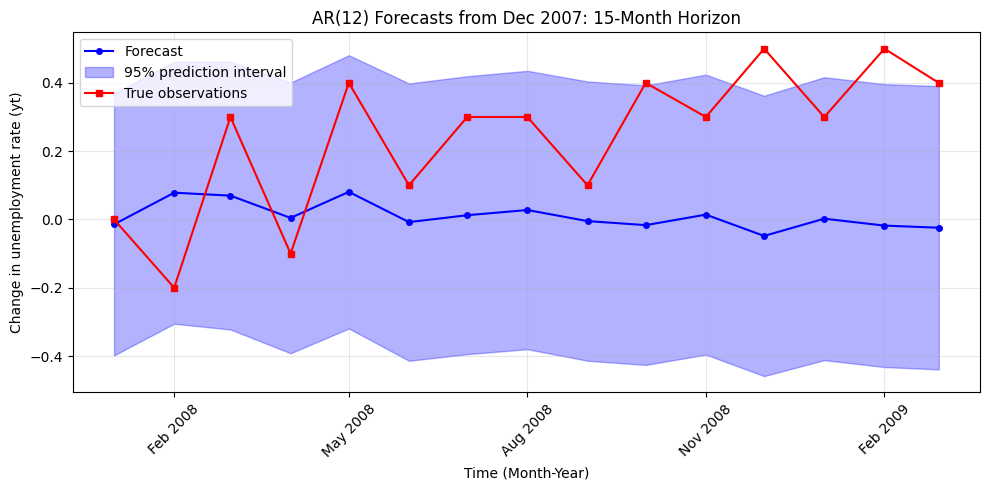

In [31]:
actual_15 = yt.loc['2008-01':'2009-03']
fig, ax = plt.subplots(figsize=(10, 5))

# Forecast
x_dates = pred_mean_15.index
ax.plot(x_dates, pred_mean_15.values, 'b-o', label='Forecast', markersize=4)
ax.fill_between(x_dates, pred_ci_15.iloc[:, 0], pred_ci_15.iloc[:, 1], alpha=0.3, color='blue', label='95% prediction interval')

# Actual
ax.plot(actual_15.index, actual_15.values, 'r-s', label='True observations', markersize=5)

ax.set_xlabel('Time (Month-Year)')
ax.set_ylabel('Change in unemployment rate (yt)')
ax.set_title('AR(12) Forecasts from Dec 2007: 15-Month Horizon')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# Date format
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()